In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [47]:
df = pd.read_csv("Spotify.csv")

df = df.drop(columns=["Unnamed: 0"], errors="ignore")
df = df.dropna()

In [48]:
df["is_hit"] = df["popularity"] >= 80

In [49]:
features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "valence",
    "tempo"
]

X = df[features]
y = df["track_genre"]

In [50]:
top_genres = df["track_genre"].value_counts().nlargest(5).index
df_small = df[df["track_genre"].isin(top_genres)]

X = df_small[features]
y = df_small["track_genre"]

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [52]:
model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train, y_train)
pred1 = model1.predict(X_test)

model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train, y_train)
pred2 = model2.predict(X_test)

model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train, y_train)
pred3 = model3.predict(X_test)

/Users/lucky/Desktop/DS2/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [53]:
print("=== Accuracy ===")
print("Logistic Regression:", accuracy_score(y_test, pred1))
print("Decision Tree:", accuracy_score(y_test, pred2))
print("Random Forest:", accuracy_score(y_test, pred3))

print("\n=== Classification Report ===")

print("\nLogistic Regression")
print(classification_report(y_test, pred1))

print("\nDecision Tree")
print(classification_report(y_test, pred2))

print("\nRandom Forest")
print(classification_report(y_test, pred3))

=== Accuracy ===
Logistic Regression: 0.629
Decision Tree: 0.587
Random Forest: 0.695

=== Classification Report ===

Logistic Regression
                   precision    recall  f1-score   support

         acoustic       0.69      0.65      0.67       216
         afrobeat       0.56      0.56      0.56       190
        power-pop       0.56      0.65      0.60       192
progressive-house       0.73      0.80      0.76       210
       psych-rock       0.58      0.48      0.52       192

         accuracy                           0.63      1000
        macro avg       0.62      0.63      0.62      1000
     weighted avg       0.63      0.63      0.63      1000


Decision Tree
                   precision    recall  f1-score   support

         acoustic       0.60      0.57      0.59       216
         afrobeat       0.57      0.56      0.56       190
        power-pop       0.54      0.56      0.55       192
progressive-house       0.73      0.74      0.73       210
       psych-rock

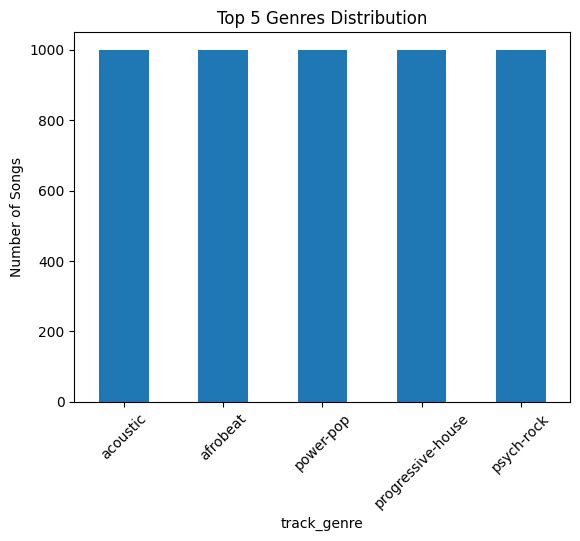

In [54]:
# Genre Distribution
df_small["track_genre"].value_counts().plot(kind="bar")
plt.title("Top 5 Genres Distribution")
plt.ylabel("Number of Songs")
plt.xticks(rotation=45)
plt.show()

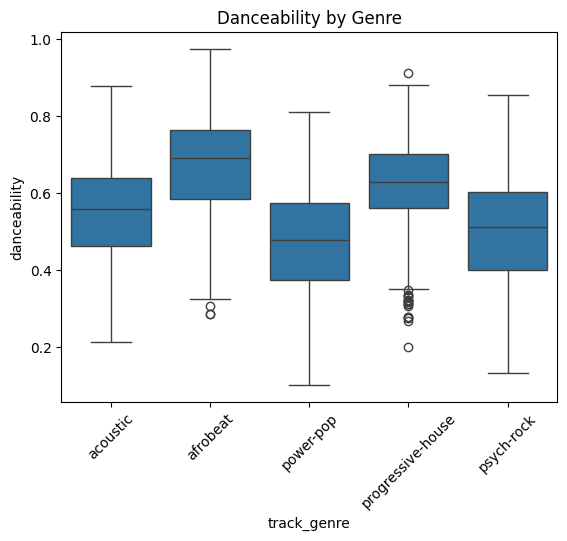

In [55]:
# Danceability by Genre
sns.boxplot(x="track_genre", y="danceability", data=df_small)
plt.title("Danceability by Genre")
plt.xticks(rotation=45)
plt.show()


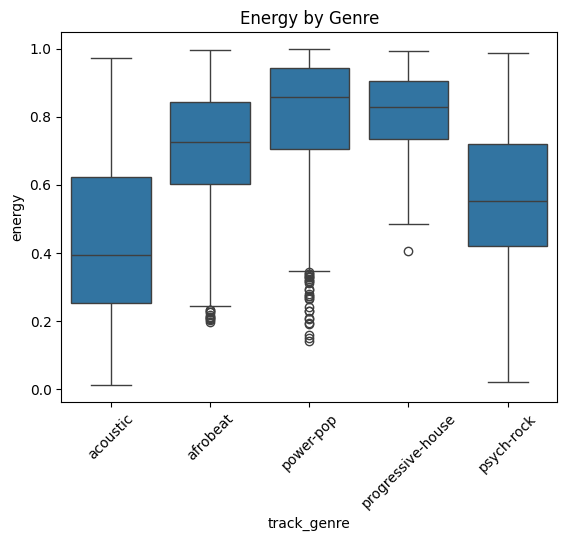

In [56]:
# Energy by Genre
sns.boxplot(x="track_genre", y="energy", data=df_small)
plt.title("Energy by Genre")
plt.xticks(rotation=45)
plt.show()

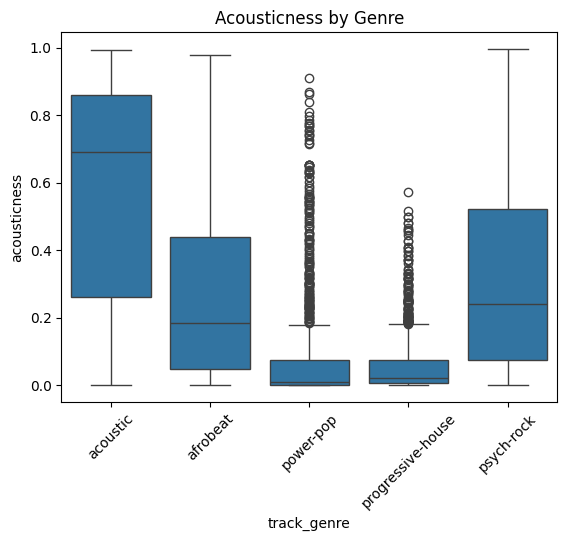

In [57]:
# Acousticness by Genre
sns.boxplot(x="track_genre", y="acousticness", data=df_small)
plt.title("Acousticness by Genre")
plt.xticks(rotation=45)
plt.show()

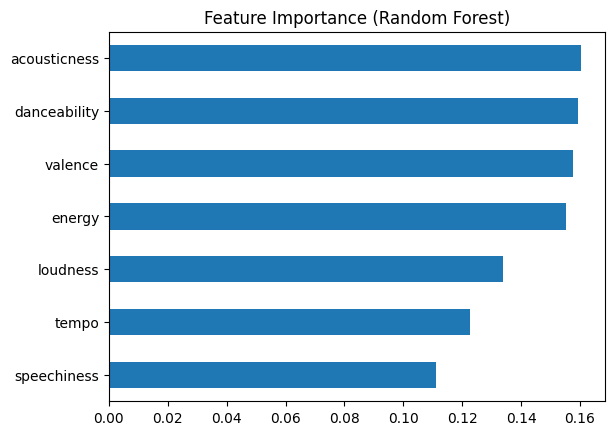

In [58]:
importance = pd.Series(model3.feature_importances_, index=features)
importance.sort_values().plot(kind="barh")
plt.title("Feature Importance (Random Forest)")
plt.show()